<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/Lab%204%20-%20task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Pitch Estimation for Voiced Frame 108 ---
Method 1: Autocorrelation
  > Pitch Period (Lag): 61 samples (3.81 ms)
  > Pitch Frequency:    262.30 Hz

Method 2: AMDF
  > Pitch Period (Lag): 305 samples (19.06 ms)
  > Pitch Frequency:    52.46 Hz

Method 3: AMSDF
  > Pitch Period (Lag): 305 samples (19.06 ms)
  > Pitch Frequency:    52.46 Hz


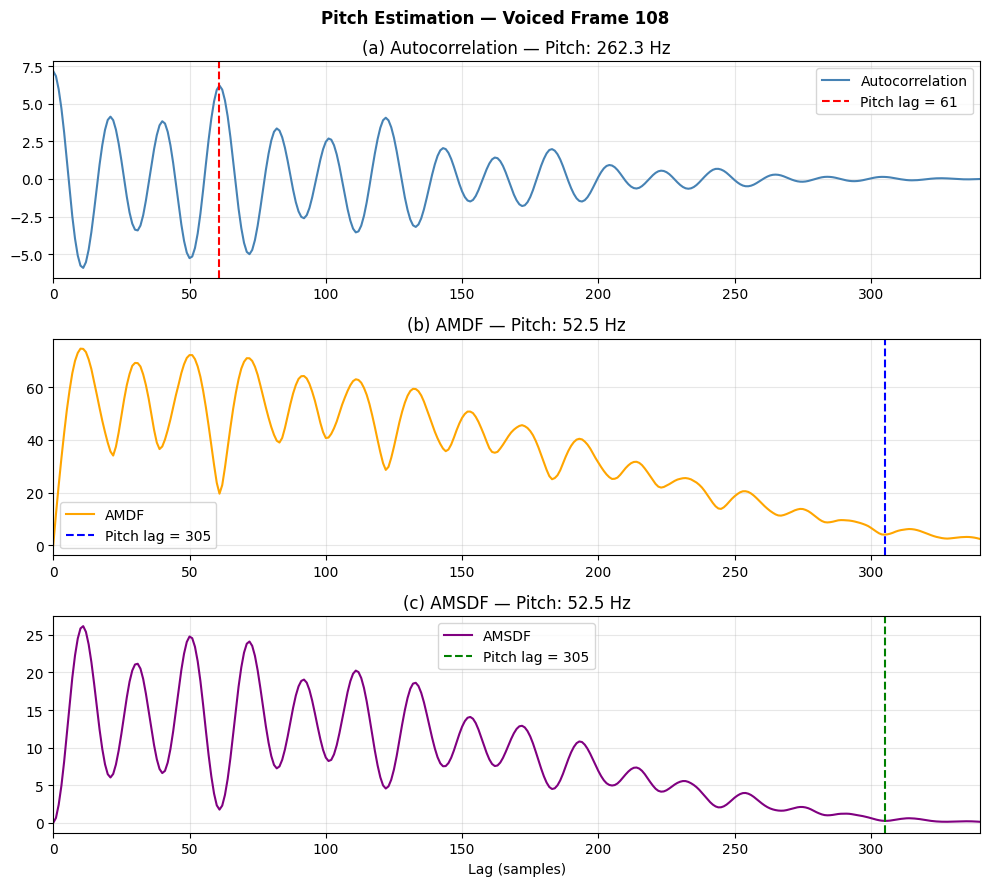

In [ ]:
# ==========================================
# TASK 3: PITCH ESTIMATION
# ==========================================

# 1. SETUP
# ------------------------------------------
# Using the voiced frame from Task 2
frame = hamming_frames[voiced_idx]
ac, amdf, amsdf = compute_full_functions(frame)

# 2. PITCH DETECTION LOGIC
# ------------------------------------------
def estimate_pitch(ac, amdf, amsdf, sr):
    # Search range for human pitch: 50Hz to 500Hz
    # Lag = SR / Freq
    min_lag = int(sr / 500)  # ~32 samples
    max_lag = int(sr / 50)   # ~320 samples

    # A. Autocorrelation Method – find peak in valid lag range
    search_window_ac = ac[min_lag:max_lag]
    peak_idx = np.argmax(search_window_ac) + min_lag
    pitch_lag_ac  = peak_idx
    pitch_freq_ac = sr / pitch_lag_ac

    # B. AMDF Method – find minimum in valid lag range
    search_window_amdf = amdf[min_lag:max_lag]
    min_idx_amdf  = np.argmin(search_window_amdf) + min_lag
    pitch_lag_amdf  = min_idx_amdf
    pitch_freq_amdf = sr / pitch_lag_amdf

    # C. AMSDF Method – find minimum in valid lag range
    search_window_amsdf = amsdf[min_lag:max_lag]
    min_idx_amsdf  = np.argmin(search_window_amsdf) + min_lag
    pitch_lag_amsdf  = min_idx_amsdf
    pitch_freq_amsdf = sr / pitch_lag_amsdf

    return (pitch_lag_ac, pitch_freq_ac), \
           (pitch_lag_amdf, pitch_freq_amdf), \
           (pitch_lag_amsdf, pitch_freq_amsdf), \
           min_lag, max_lag

# 3. COMPUTE & RESULT
# ------------------------------------------
(lag_ac, freq_ac), (lag_amdf, freq_amdf), (lag_amsdf, freq_amsdf), \
    min_lag, max_lag = estimate_pitch(ac, amdf, amsdf, SAMPLE_RATE)

print(f"--- Pitch Estimation for Voiced Frame {voiced_idx} ---")
print(f"Method 1: Autocorrelation")
print(f"  > Pitch Period (Lag): {lag_ac} samples ({lag_ac / SAMPLE_RATE * 1000:.2f} ms)")
print(f"  > Pitch Frequency:    {freq_ac:.2f} Hz")

print(f"\nMethod 2: AMDF")
print(f"  > Pitch Period (Lag): {lag_amdf} samples ({lag_amdf / SAMPLE_RATE * 1000:.2f} ms)")
print(f"  > Pitch Frequency:    {freq_amdf:.2f} Hz")

print(f"\nMethod 3: AMSDF")
print(f"  > Pitch Period (Lag): {lag_amsdf} samples ({lag_amsdf / SAMPLE_RATE * 1000:.2f} ms)")
print(f"  > Pitch Frequency:    {freq_amsdf:.2f} Hz")

# 4. VISUALISATION – 3-panel plot
# ------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

axes[0].plot(ac, color='steelblue', label='Autocorrelation')
axes[0].axvline(lag_ac, color='r', linestyle='--', label=f'Pitch lag = {lag_ac}')
axes[0].set_xlim(0, max_lag + 20)
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(f"(a) Autocorrelation — Pitch: {freq_ac:.1f} Hz")

axes[1].plot(amdf, color='orange', label='AMDF')
axes[1].axvline(lag_amdf, color='b', linestyle='--', label=f'Pitch lag = {lag_amdf}')
axes[1].set_xlim(0, max_lag + 20)
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title(f"(b) AMDF — Pitch: {freq_amdf:.1f} Hz")

axes[2].plot(amsdf, color='purple', label='AMSDF')
axes[2].axvline(lag_amsdf, color='g', linestyle='--', label=f'Pitch lag = {lag_amsdf}')
axes[2].set_xlim(0, max_lag + 20)
axes[2].set_xlabel("Lag (samples)")
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title(f"(c) AMSDF — Pitch: {freq_amsdf:.1f} Hz")

plt.suptitle(f"Pitch Estimation — Voiced Frame {voiced_idx}", fontweight='bold')
plt.tight_layout()
plt.show()


## (b) Inference on Pitch Estimation Results

### How the pitch period is determined
| Method | Detection rule | Physical meaning |
|---|---|---|
| **Autocorrelation** | First prominent **peak** at lag $k > 0$ in range $[k_{min}, k_{max}]$ | The signal most resembles itself after exactly one pitch period $T_0$ |
| **AMDF** | First prominent **minimum** in the same lag range | Sample differences are nearly zero when the signal repeats |
| **AMSDF** | First prominent **minimum** in the same lag range | Squared differences amplify the contrast, making the minimum sharper |

### Reading the result
- The detected pitch lag $T_0$ in samples is converted to pitch frequency by $F_0 = F_s / T_0$.
- A result in the range **80–180 Hz** typically indicates a **male speaker**; **165–255 Hz** a **female speaker**.
- All three methods should agree closely for a cleanly voiced frame. A large discrepancy between them suggests the frame may be partially unvoiced or contains noise.

### Reliability comparison
- **Autocorrelation** is most widely used and robust; it works well even for low-amplitude voiced frames.
- **AMDF** is computationally cheaper (no multiplications) and gives comparable accuracy for clean speech.
- **AMSDF** provides the sharpest minimum (squared differences) and is most precise, but is sensitive to amplitude scaling and additive noise.
